In [1]:
#WEEK2 TASK1 CODE1

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [5]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [6]:
pima_df = pd.read_csv(url, header=None, names=columns)

In [8]:
print("Dataset Shape (rows, cols):", pima_df.shape)

Dataset Shape (rows, cols): (768, 9)


In [7]:
print("\nFirst 3 rows of raw dataset:")


First 3 rows of raw dataset:


In [9]:
print(pima_df.head(3))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  


In [10]:
zero_counts = (pima_df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()

In [11]:
print("\nInvalid Zero Values per column:\n", zero_counts)


Invalid Zero Values per column:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
#TASK1 CODE2

In [22]:
from sklearn.impute import SimpleImputer

In [23]:
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [24]:
pima_df[cols_to_impute] = pima_df[cols_to_impute].replace(0, np.nan)

In [25]:
print("Missing values after marking zeros:\n", pima_df.isnull().sum())

Missing values after marking zeros:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [26]:
imputer = SimpleImputer(strategy='median')

In [27]:
pima_df[cols_to_impute] = imputer.fit_transform(pima_df[cols_to_impute])

In [28]:
print("\nMissing values after statistical median imputation:\n", pima_df.isnull().sum())


Missing values after statistical median imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [29]:
#TASK1 CODE3

In [30]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [31]:
features = columns[:-1]

In [32]:
X = pima_df[features]

In [33]:
min_max_scaler = MinMaxScaler()

In [34]:
X_normalized = min_max_scaler.fit_transform(X)

In [35]:
print("Normalized Range Boundaries (Min/Max):", X_normalized.min(), "to", X_normalized.max())

Normalized Range Boundaries (Min/Max): 0.0 to 1.0000000000000002


In [36]:
standard_scaler = StandardScaler()

In [37]:
X_standardized = standard_scaler.fit_transform(X)

In [38]:
print("Standardized Mean (approx 0):", round(X_standardized.mean(), 4))

Standardized Mean (approx 0): 0.0


In [39]:
print("Standardized Std Dev (approx 1):", round(X_standardized.std(), 4))

Standardized Std Dev (approx 1): 1.0


In [ ]:
#TASK1 CODE4

In [42]:
from sklearn.preprocessing import PowerTransformer

In [43]:
original_skew = pima_df['Insulin'].skew()

In [44]:
print("Original skewness coefficient of 'Insulin':", round(original_skew, 4))

Original skewness coefficient of 'Insulin': 3.38


In [45]:
power_transformer = PowerTransformer(method='yeo-johnson')

In [46]:
insulin_transformed = power_transformer.fit_transform(pima_df[['Insulin']])

In [47]:
transformed_skew = pd.Series(insulin_transformed.flatten()).skew()

In [48]:
print("Skewness coefficient after Power Transformation:", round(transformed_skew, 4))

Skewness coefficient after Power Transformation: 0.0276


In [49]:
#task1code5

In [50]:
processed_pima_df = pd.DataFrame(data=X_standardized, columns=features)

In [51]:
processed_pima_df['Outcome'] = pima_df['Outcome']

In [52]:
processed_pima_df.to_csv("processed_pima_diabetes.csv", index=False)

In [53]:
print("Processed Pima dataset exported successfully to 'processed_pima_diabetes.csv'. Shape:", processed_pima_df.shape)

Processed Pima dataset exported successfully to 'processed_pima_diabetes.csv'. Shape: (768, 9)


In [ ]:
#TASK2 CODE1

In [54]:
import pandas as pd

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [57]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [58]:
sonar_columns = sonar_features + ['Class']

In [59]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [60]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [61]:
X_sonar = sonar_df[sonar_features]

In [62]:
scaler = StandardScaler()

In [63]:
X_sonar_scaled = scaler.fit_transform(X_sonar)

In [64]:
print("Standardized features shape:", X_sonar_scaled.shape)

Standardized features shape: (208, 60)


In [ ]:
#TASK2 CODE2

In [65]:
from sklearn.decomposition import PCA

In [66]:
pca_90 = PCA(n_components=0.90, random_state=42)

In [67]:
X_pca_90 = pca_90.fit_transform(X_sonar_scaled)

In [68]:
print("Original dimensions count:", X_sonar_scaled.shape[1])

Original dimensions count: 60


In [69]:
print("Reduced dimensions count (to preserve 90% variance):", X_pca_90.shape[1])

Reduced dimensions count (to preserve 90% variance): 22


In [ ]:
#TASK2CODE3

In [70]:
import matplotlib.pyplot as plt

In [71]:
import numpy as np

In [72]:
pca_full = PCA(random_state=42)

In [73]:
pca_full.fit(X_sonar_scaled)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,42


In [75]:
plt.figure(figsize=(7, 4))

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

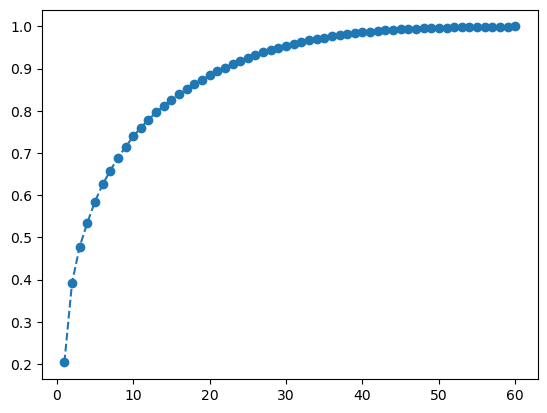

In [76]:
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

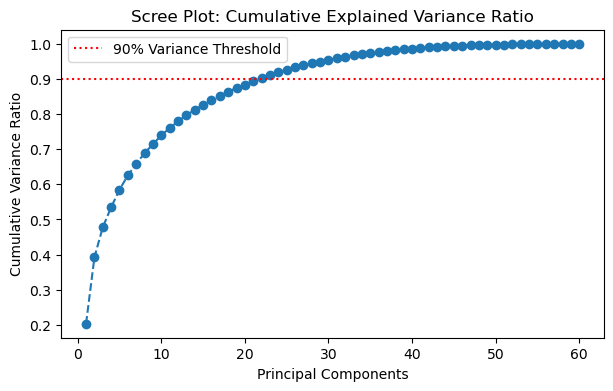

In [77]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
plt.title("Scree Plot: Cumulative Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.show()

In [78]:
#TASK2 CODE4

In [79]:
from sklearn.manifold import TSNE

In [80]:
import seaborn as sns

In [81]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

In [83]:
X_tsne = tsne.fit_transform(X_sonar_scaled)

In [85]:
tsne_df = pd.DataFrame(X_tsne, columns=['Dim_1', 'Dim_2'])

In [86]:
tsne_df['Class'] = sonar_df['Class']

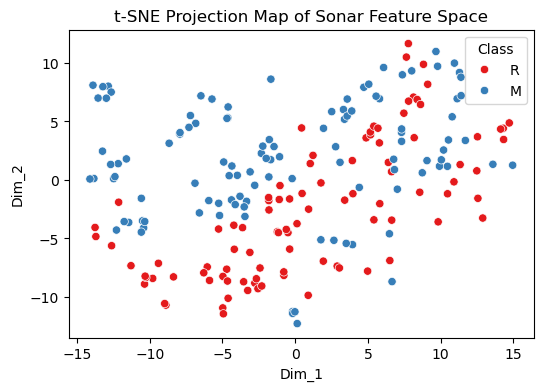

In [87]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue='Class', palette='Set1')
plt.title("t-SNE Projection Map of Sonar Feature Space")
plt.show()

In [ ]:
#TASK2 CODE5

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
from sklearn.model_selection import train_test_split

In [90]:
from sklearn.metrics import accuracy_score

In [91]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sonar_scaled, sonar_df['Class_numeric'], test_size=0.3, random_state=42)

In [92]:
lr_raw = LogisticRegression()

In [93]:
lr_raw.fit(X_train_raw, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [94]:
acc_raw = accuracy_score(y_test, lr_raw.predict(X_test_raw))

In [95]:
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_90, sonar_df['Class_numeric'], test_size=0.3, random_state=42)

In [96]:
lr_pca = LogisticRegression()

In [97]:
lr_pca.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [98]:
acc_pca = accuracy_score(y_test, lr_pca.predict(X_test_pca))

In [99]:
print(f"Accuracy using all 60 scaled features: {acc_raw * 100:.2f}%")

Accuracy using all 60 scaled features: 76.19%


In [100]:
print(f"Accuracy using {X_pca_90.shape[1]} PCA components:  {acc_pca * 100:.2f}%")

Accuracy using 22 PCA components:  87.30%


In [ ]:
#TASK3 CODE1

In [101]:
from sklearn.feature_selection import SelectKBest, f_classif

In [102]:
selector = SelectKBest(score_func=f_classif, k=4)

In [103]:
selector.fit(X_standardized, pima_df['Outcome'])

,score_func,<function f_c...x7c48fd7d1940>
,k,4


In [104]:
anova_scores = pd.DataFrame({'Feature': features, 'F-Score': selector.scores_}).sort_values(by='F-Score', ascending=False)

In [105]:
print("ANOVA F-Test Scores:\n", anova_scores)

ANOVA F-Test Scores:
                     Feature     F-Score
1                   Glucose  245.667855
5                       BMI   82.629271
7                       Age   46.140611
0               Pregnancies   39.670227
3             SkinThickness   37.078538
4                   Insulin   33.190796
6  DiabetesPedigreeFunction   23.871300
2             BloodPressure   21.631580


In [ ]:
#TASK3 CODE2

In [106]:
from sklearn.feature_selection import RFE

In [107]:
from sklearn.linear_model import LogisticRegression

In [108]:
estimator = LogisticRegression()

In [109]:
rfe = RFE(estimator=estimator, n_features_to_select=4)

In [110]:
rfe.fit(X_standardized, pima_df['Outcome'])

,estimator,LogisticRegression()
,n_features_to_select,4
,step,1
,verbose,0
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [111]:
rfe_support = pd.DataFrame({'Feature': features, 'Selected': rfe.support_, 'Ranking': rfe.ranking_}).sort_values(by='Ranking')

In [112]:
print("RFE Selected Features:\n", rfe_support)

RFE Selected Features:
                     Feature  Selected  Ranking
0               Pregnancies      True        1
1                   Glucose      True        1
6  DiabetesPedigreeFunction      True        1
5                       BMI      True        1
7                       Age     False        2
2             BloodPressure     False        3
4                   Insulin     False        4
3             SkinThickness     False        5


In [ ]:
#TASK3 CODE3

In [113]:
from sklearn.linear_model import LogisticRegression

In [114]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)

In [115]:
lasso.fit(X_standardized, pima_df['Outcome'])

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [116]:
lasso_coefs = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)

In [117]:
print("RFE Selected Features:\n", rfe_support)

RFE Selected Features:
                     Feature  Selected  Ranking
0               Pregnancies      True        1
1                   Glucose      True        1
6  DiabetesPedigreeFunction      True        1
5                       BMI      True        1
7                       Age     False        2
2             BloodPressure     False        3
4                   Insulin     False        4
3             SkinThickness     False        5


In [ ]:
#TASK3 CODE4

In [118]:
from sklearn.linear_model import LogisticRegression

In [119]:
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)

In [120]:
lasso.fit(X_standardized, pima_df['Outcome'])

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [121]:
lasso_coefs = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)

In [122]:
print("Lasso Regularization Coefficients:\n", lasso_coefs)

Lasso Regularization Coefficients:
                     Feature  Coefficient
1                   Glucose     1.106412
5                       BMI     0.611338
0               Pregnancies     0.399515
6  DiabetesPedigreeFunction     0.269034
7                       Age     0.134767
2             BloodPressure    -0.073190
4                   Insulin    -0.067230
3             SkinThickness     0.019400


In [123]:
#TASK3 CODE5

In [124]:
from sklearn.ensemble import RandomForestClassifier

In [125]:
import matplotlib.pyplot as plt

In [126]:
import seaborn as sns

In [127]:
import warnings

In [128]:
warnings.filterwarnings("ignore")

In [129]:
rf = RandomForestClassifier(random_state=42)

In [130]:
rf.fit(X, pima_df['Outcome'])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [131]:
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)

In [132]:
print("Random Forest Feature Importances:\n", importances)

Random Forest Feature Importances:
                     Feature  Importance
1                   Glucose    0.263715
5                       BMI    0.167470
7                       Age    0.127208
6  DiabetesPedigreeFunction    0.124075
4                   Insulin    0.084843
2             BloodPressure    0.082722
0               Pregnancies    0.079268
3             SkinThickness    0.070699


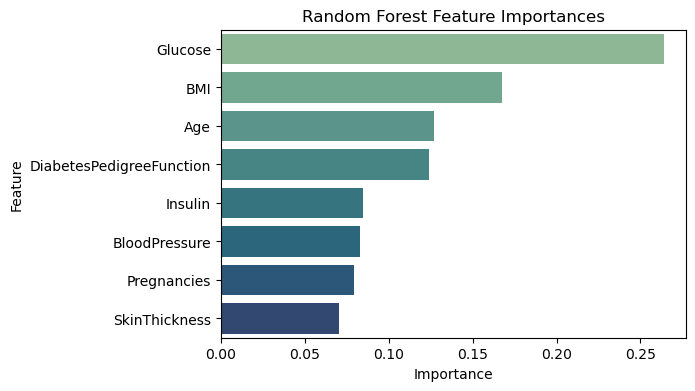

In [133]:

plt.figure(figsize=(6, 4))
sns.barplot(data=importances, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Feature Importances")
plt.show()

In [ ]:
#TASK3 CODE6

In [134]:
from sklearn.model_selection import train_test_split

In [135]:
from sklearn.metrics import classification_report

In [136]:
X_train, X_test, y_train_p, y_test_p = train_test_split(X, pima_df['Outcome'], test_size=0.3, random_state=42)


In [137]:
rf_full = RandomForestClassifier(random_state=42)

In [138]:
rf_full.fit(X_train, y_train_p)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
preds_full = rf_full.predict(X_test)

In [140]:
top_4_cols = importances.head(4)['Feature'].tolist()

In [141]:
X_train_sub = X_train[top_4_cols]

In [142]:
X_test_sub = X_test[top_4_cols]

In [143]:

rf_sub = RandomForestClassifier(random_state=42)

In [144]:
rf_sub.fit(X_train_sub, y_train_p)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [145]:
preds_sub = rf_sub.predict(X_test_sub)

In [146]:
print("--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---")
print(classification_report(y_test_p, preds_full))

--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.63      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.72      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231



In [147]:
print("\n--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---")
print(classification_report(y_test_p, preds_sub))



--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       151
           1       0.60      0.68      0.64        80

    accuracy                           0.73       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.73      0.73       231

